# 🎓 Week 7–8 Capstone Project: Hybrid NLP-Based Job Recommendation and Resume–Job Matching System
### Independent AI/ML Research Challenge
**Author:** Ahmad  
**Problem:** Hybrid NLP Matching (Sentence-BERT + Skill Extraction + Structured Features + XGBoost)  
**Dataset:** Hugging Face `0xnbk/resume-ats-score-v1-en` (~6,400 samples)  
**Deliverables:** Preprocessing, EDA, 3 Baselines, Hybrid Improvement, Evaluation, Gradio App, IEEE Paper Assets.


## 🛠️ Step 0: Install Dependencies & GPU Setup


In [1]:
# Install required libraries
!pip install -q datasets sentence-transformers xgboost lightgbm gradio scikit-learn matplotlib seaborn plotly wordcloud tabulate

import os
import sys
import re
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch

from datasets import load_dataset
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack
from sentence_transformers import SentenceTransformer
import xgboost as xgb

# Set random seed
RANDOM_STATE = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")
os.makedirs("models", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Environment ready. Using device: {device.upper()}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


✅ Environment ready. Using device: CUDA
   GPU: Tesla T4


---
# 📚 Part 1, 2 & 3: Problem Statement, Literature Review & Dataset Loading

### 1. Problem Statement
Traditional ATS filters rely on rigid keyword matching, missing candidates with semantically equivalent skills ("led a team" vs "management experience"). We build a hybrid matching engine combining **Sentence-BERT semantic embeddings**, **explicit skill extraction**, and **structured text features** to predict ATS scores with explainability.

### 2. Literature Review Summary (5 Key Papers)
1. **Zhu et al. (2021)**: *Reciprocal-Constrained Interpretable Job Recommendation* — Considers bilateral recruiter/candidate goals with explainability.
2. **Panchasara et al. (2023)**: *AI Based Job Recommendation System using BERT* — Validates BERT contextual representations over keywords.
3. **Mao et al. (2023)**: *Job Recommendation based on Attention Layer Scoring & Tensor Decomposition* — Combines behavioral attention and content.
4. **Guan et al. (2024)**: *JobFormer: Skill-Aware Job Recommendation with Semantic Transformer* — Demonstrates skill-aware attention improves matching.
5. **Han et al. (2024)**: *Adapting Job Recommendations to User Preference Drift (BISTRO)* — Behavioral-semantic fusion framework.

### 3. Dataset Discovery
Dataset: `0xnbk/resume-ats-score-v1-en` (Hugging Face)  
Features: `text` (resume + JD separated by ` SEP `), `ats_score` (18.3–90.7), `original_label` (No Fit, Potential Fit, Good Fit).


In [2]:
# Load dataset from Hugging Face
print("[INFO] Loading dataset from Hugging Face...")
ds = load_dataset("0xnbk/resume-ats-score-v1-en")

train_raw = ds["train"].to_pandas()
val_raw = ds["validation"].to_pandas()

print(f"  Train split: {len(train_raw):,} rows")
print(f"  Validation split: {len(val_raw):,} rows")

def parse_combined_text(df):
    df = df.copy()
    resumes, jds = [], []
    for t in df["text"]:
        t_str = str(t)
        if " SEP " in t_str:
            parts = t_str.split(" SEP ", maxsplit=1)
            resumes.append(parts[0].strip())
            jds.append(parts[1].strip())
        else:
            mid = len(t_str) // 2
            resumes.append(t_str[:mid].strip())
            jds.append(t_str[mid:].strip())
    df["resume_text"] = resumes
    df["jd_text"] = jds
    return df

train_df = parse_combined_text(train_raw)
val_df = parse_combined_text(val_raw)

print(f"✅ Text parsed successfully!")
print(f"   Avg Resume length: {train_df['resume_text'].str.len().mean():.0f} chars")
print(f"   Avg JD length:     {train_df['jd_text'].str.len().mean():.0f} chars")
train_df[["ats_score", "original_label", "resume_text", "jd_text"]].head(3)


[INFO] Loading dataset from Hugging Face...


README.md:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

train.csv: reconstructing file:   0%|          |  0.00B / 43.3MB            

train.csv: downloading bytes:           |  0.00B            

validation.csv: reconstructing file:   0%|          |  0.00B / 10.7MB            

validation.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5099 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1275 [00:00<?, ? examples/s]

  Train split: 5,099 rows
  Validation split: 1,275 rows
✅ Text parsed successfully!
   Avg Resume length: 5733 chars
   Avg JD length:     2738 chars


,ats_score,original_label,resume_text,jd_text
0,80.6,Good Fit,SummaryI am seeking a position wherein I may u...,- Share resume to shan imrsoft.com Job Title J...
1,24.3,No Fit,ProfileHighly motivated Sales Associate with e...,Purpose StatementThe Software Engineering Mana...
2,53.9,Potential Fit,SummaryHaving achieved a milestone of 7 years ...,"Title Business AnalystLocation Santa Clara, CA..."


---
# 🧹 Part 4: Data Preprocessing (with Justifications)

**Every preprocessing step is justified:**
1. **Missing values**: Ensure complete text and valid continuous targets.
2. **Text Cleaning**: Lowercase, remove emails/URLs/special punctuation to standardize token representations.
3. **Ordinal Label Encoding**: No Fit=0, Potential Fit=1, Good Fit=2 (preserves natural progression).
4. **Feature Engineering**:
   - `resume_char_len`, `jd_char_len`, `resume_word_count`, `jd_word_count`: capture detail density.
   - `length_ratio`: ratio of resume length to JD length.
   - `keyword_overlap_ratio`: direct proxy for basic ATS keyword match.
5. **Stratified Split**: 80% train / 20% test holdout preserving class balance (`random_state=42`).


In [3]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+\.\S+", " ", text)
    text = re.sub(r"[\+]?[(]?[0-9]{1,4}[)]?[-\s\./0-9]{7,}", " ", text)
    text = re.sub(r"[^a-z0-9\s\.\,\;\:\-\/\(\)\+\#]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

LABEL_MAP = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}

def preprocess_df(df):
    df = df.copy().dropna(subset=["ats_score"])
    df["resume_clean"] = df["resume_text"].apply(clean_text)
    df["jd_clean"] = df["jd_text"].apply(clean_text)
    df["label_encoded"] = df["original_label"].map(LABEL_MAP).fillna(0).astype(int)

    # Length features
    df["resume_char_len"] = df["resume_clean"].str.len()
    df["jd_char_len"] = df["jd_clean"].str.len()
    df["resume_word_count"] = df["resume_clean"].str.split().str.len()
    df["jd_word_count"] = df["jd_clean"].str.split().str.len()
    df["length_ratio"] = df["resume_char_len"] / (df["jd_char_len"] + 1)

    # Keyword overlap
    def calc_overlap(row):
        rw = set(str(row["resume_clean"]).split())
        jw = set(str(row["jd_clean"]).split())
        return len(rw & jw) / max(len(jw), 1)

    df["keyword_overlap_ratio"] = df.apply(calc_overlap, axis=1)
    return df

train_clean = preprocess_df(train_df)
val_clean = preprocess_df(val_df)

# Train/Test 80/20 Stratified Split
train_data, test_data = train_test_split(
    train_clean, test_size=0.2, random_state=42, stratify=train_clean["label_encoded"]
)

print(f"✅ Preprocessing Complete:")
print(f"   Train set: {len(train_data):,} samples")
print(f"   Test set:  {len(test_data):,} samples")
print(f"   Val set:   {len(val_clean):,} samples")


✅ Preprocessing Complete:
   Train set: 4,079 samples
   Test set:  1,020 samples
   Val set:   1,275 samples


---
# 📊 Part 5: Exploratory Data Analysis (EDA)


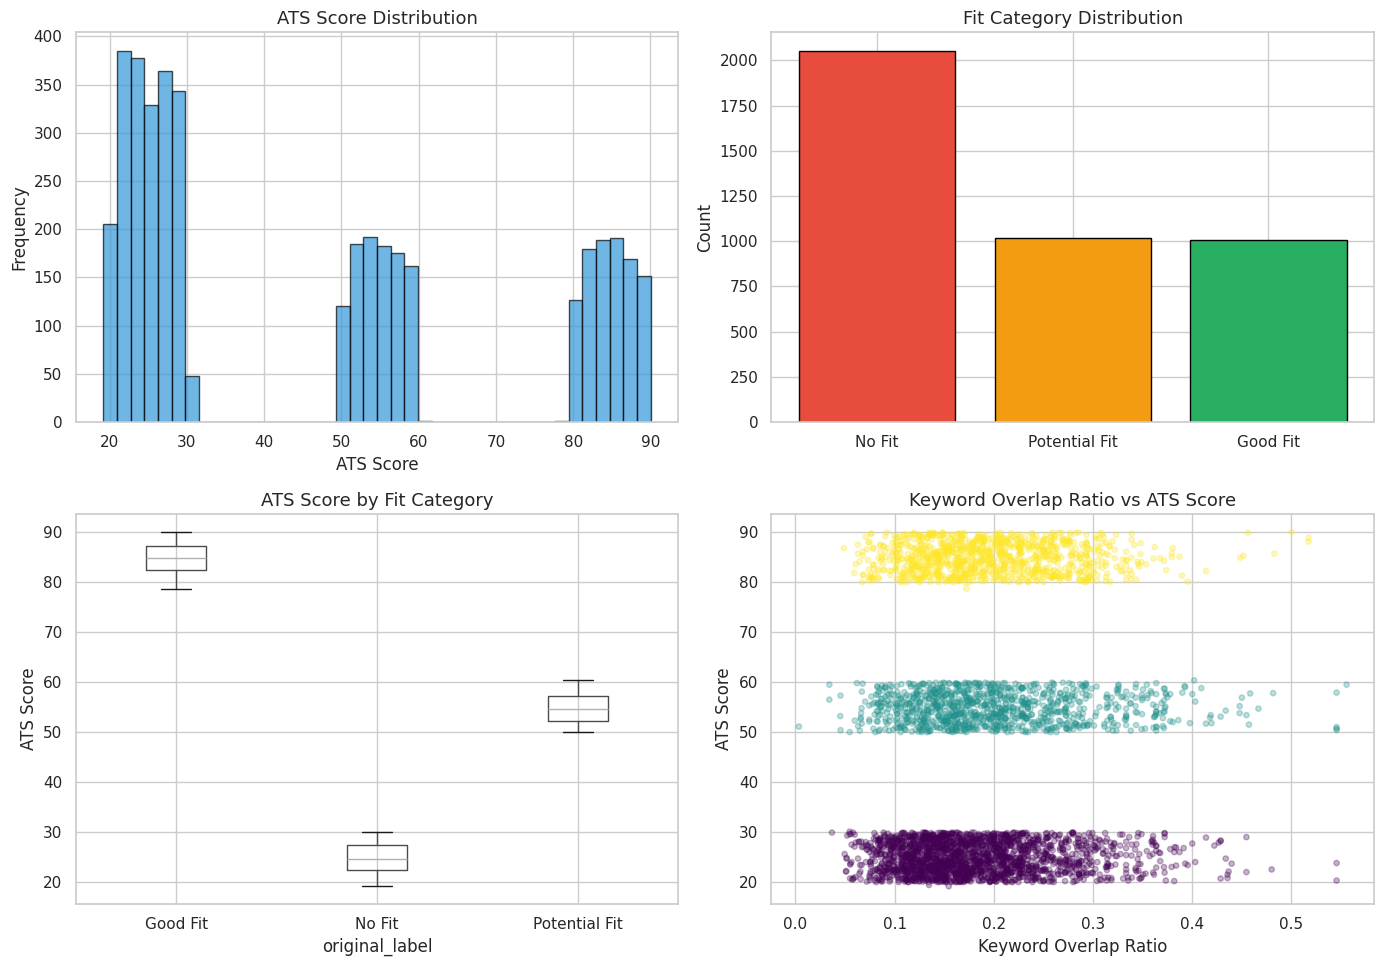

📊 Key EDA Statistics:
                 count   mean   std    min   25%    50%   75%    max
original_label                                                      
Good Fit        1009.0  84.84  2.85  78.66  82.4  84.82  87.2  90.05
No Fit          2052.0  24.89  2.89  19.16  22.4  24.70  27.4  30.07
Potential Fit   1018.0  54.80  2.88  50.00  52.3  54.70  57.3  60.36


In [4]:
# EDA Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Score distribution
axes[0, 0].hist(train_data["ats_score"], bins=40, color="#3498db", edgecolor="black", alpha=0.7)
axes[0, 0].set_title("ATS Score Distribution", fontsize=13)
axes[0, 0].set_xlabel("ATS Score")
axes[0, 0].set_ylabel("Frequency")

# 2. Label count
counts = train_data["original_label"].value_counts()
axes[0, 1].bar(counts.index, counts.values, color=["#e74c3c", "#f39c12", "#27ae60"], edgecolor="black")
axes[0, 1].set_title("Fit Category Distribution", fontsize=13)
axes[0, 1].set_ylabel("Count")

# 3. Score by Category
train_data.boxplot(column="ats_score", by="original_label", ax=axes[1, 0])
axes[1, 0].set_title("ATS Score by Fit Category", fontsize=13)
axes[1, 0].set_ylabel("ATS Score")

# 4. Keyword Overlap vs Score
axes[1, 1].scatter(train_data["keyword_overlap_ratio"], train_data["ats_score"], alpha=0.3, s=15, c=train_data["label_encoded"], cmap="viridis")
axes[1, 1].set_title("Keyword Overlap Ratio vs ATS Score", fontsize=13)
axes[1, 1].set_xlabel("Keyword Overlap Ratio")
axes[1, 1].set_ylabel("ATS Score")

plt.suptitle("")
plt.tight_layout()
plt.savefig("outputs/figures/eda_summary.png", dpi=200)
plt.show()

print("📊 Key EDA Statistics:")
print(train_data.groupby("original_label")["ats_score"].describe().round(2))


---
# ⚙️ Part 6: Baseline Models Training
We train three diverse baselines:
1. **TF-IDF + Ridge Regression**: Linear keyword model.
2. **TF-IDF + Random Forest**: Non-linear ensemble model.
3. **Sentence-BERT + Ridge Regression**: Deep semantic embedding model (`all-MiniLM-L6-v2`).


In [5]:
# Metrics computation functions
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Categorical classification metrics (thresholds <40, 40-65, >=65)
    def to_label(s):
        return np.where(s < 40, 0, np.where(s < 65, 1, 2))

    yt_l = to_label(y_true)
    yp_l = to_label(y_pred)
    p = precision_score(yt_l, yp_l, average="weighted", zero_division=0)
    r = recall_score(yt_l, yp_l, average="weighted", zero_division=0)
    f1 = f1_score(yt_l, yp_l, average="weighted", zero_division=0)

    # nDCG@10
    pred_order = np.argsort(-y_pred)[:10]
    ideal_order = np.argsort(-y_true)[:10]
    dcg = sum(y_true[pred_order[i]] / np.log2(i + 2) for i in range(min(10, len(pred_order))))
    idcg = sum(y_true[ideal_order[i]] / np.log2(i + 2) for i in range(min(10, len(ideal_order))))
    ndcg = (dcg / idcg) if idcg > 0 else 0.0

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "Precision": p, "Recall": r, "F1": f1, "nDCG@10": ndcg}

y_train = train_data["ats_score"].values
y_test = test_data["ats_score"].values

# ── 1. TF-IDF Extraction ──
print("[1/3] Extracting TF-IDF Features...")
vec_res = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), stop_words="english", sublinear_tf=True)
vec_jd = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), stop_words="english", sublinear_tf=True)

X_tr_res = vec_res.fit_transform(train_data["resume_clean"])
X_tr_jd = vec_jd.fit_transform(train_data["jd_clean"])
X_te_res = vec_res.transform(test_data["resume_clean"])
X_te_jd = vec_jd.transform(test_data["jd_clean"])

cos_tr = np.array([cosine_similarity(X_tr_res[i], X_tr_jd[i])[0, 0] for i in range(X_tr_res.shape[0])]).reshape(-1, 1)
cos_te = np.array([cosine_similarity(X_te_res[i], X_te_jd[i])[0, 0] for i in range(X_te_res.shape[0])]).reshape(-1, 1)

X_tr_tfidf = np.hstack([hstack([X_tr_res, X_tr_jd]).toarray(), cos_tr])
X_te_tfidf = np.hstack([hstack([X_te_res, X_te_jd]).toarray(), cos_te])

# Baseline 1: TF-IDF + Ridge
ridge_bl = Ridge(alpha=1.0, random_state=42)
ridge_bl.fit(X_tr_tfidf, y_train)
y_pred_ridge = ridge_bl.predict(X_te_tfidf)
res_ridge = compute_metrics(y_test, y_pred_ridge)
print("   Baseline 1 (TF-IDF + Ridge) MAE:", round(res_ridge['MAE'], 4))

# Baseline 2: TF-IDF + Random Forest
print("[2/3] Training Baseline 2 (TF-IDF + Random Forest)...")
rf_bl = RandomForestRegressor(n_estimators=150, max_depth=18, min_samples_split=4, random_state=42, n_jobs=-1)
rf_bl.fit(X_tr_tfidf, y_train)
y_pred_rf = rf_bl.predict(X_te_tfidf)
res_rf = compute_metrics(y_test, y_pred_rf)
print("   Baseline 2 (TF-IDF + RF) MAE:", round(res_rf['MAE'], 4))

# ── 2. SBERT Extraction ──
print("[3/3] Encoding with Sentence-BERT on", device.upper(), "...")
sbert = SentenceTransformer("all-MiniLM-L6-v2", device=device)

tr_res_emb = sbert.encode(train_data["resume_clean"].tolist(), batch_size=128, show_progress_bar=True, convert_to_numpy=True)
tr_jd_emb = sbert.encode(train_data["jd_clean"].tolist(), batch_size=128, show_progress_bar=True, convert_to_numpy=True)
te_res_emb = sbert.encode(test_data["resume_clean"].tolist(), batch_size=128, show_progress_bar=True, convert_to_numpy=True)
te_jd_emb = sbert.encode(test_data["jd_clean"].tolist(), batch_size=128, show_progress_bar=True, convert_to_numpy=True)

tr_sbert_cos = np.array([cosine_similarity(tr_res_emb[i:i+1], tr_jd_emb[i:i+1])[0, 0] for i in range(len(tr_res_emb))])
te_sbert_cos = np.array([cosine_similarity(te_res_emb[i:i+1], te_jd_emb[i:i+1])[0, 0] for i in range(len(te_res_emb))])

X_tr_sbert = np.column_stack([tr_sbert_cos, np.abs(tr_res_emb - tr_jd_emb)])
X_te_sbert = np.column_stack([te_sbert_cos, np.abs(te_res_emb - te_jd_emb)])

sbert_ridge = Ridge(alpha=1.0, random_state=42)
sbert_ridge.fit(X_tr_sbert, y_train)
y_pred_sbert = sbert_ridge.predict(X_te_sbert)
res_sbert = compute_metrics(y_test, y_pred_sbert)
print("   Baseline 3 (SBERT + Ridge) MAE:", round(res_sbert['MAE'], 4))


[1/3] Extracting TF-IDF Features...
   Baseline 1 (TF-IDF + Ridge) MAE: 18.2683
[2/3] Training Baseline 2 (TF-IDF + Random Forest)...
   Baseline 2 (TF-IDF + RF) MAE: 17.6113
[3/3] Encoding with Sentence-BERT on CUDA ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

   Baseline 3 (SBERT + Ridge) MAE: 18.7814


---
# 🚀 Part 7 & 8: Proposed Improvement — Multi-Signal Hybrid Model

We fuse three complementary signals:
1. **Semantic Similarity Vector** (SBERT cosine similarity + 384D embedding absolute difference)
2. **Explicit Skill Overlap** (Curated technical & soft skills dictionary matching)
3. **Engineered Text Metadata** (Word counts, character lengths, length ratio, keyword overlap)

Trained with a tuned **XGBoost Meta-Learner** to capture non-linear feature interactions and optimal weighting.


In [7]:
!nvidia-smi

Wed Aug 19 09:32:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             34W /   70W |    1053MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
# Skill Dictionary
TECH_SKILLS = {
    "python", "java", "javascript", "typescript", "c++", "c#", "ruby", "go", "rust", "scala", "kotlin", "swift", "php", "r",
    "react", "angular", "vue", "node.js", "nodejs", "django", "flask", "spring", "express", "fastapi", "next.js",
    "machine learning", "deep learning", "natural language processing", "nlp", "computer vision", "tensorflow", "pytorch", "keras", "scikit-learn",
    "pandas", "numpy", "spark", "hadoop", "data analysis", "data science", "neural network",
    "aws", "azure", "gcp", "docker", "kubernetes", "ci/cd", "jenkins", "terraform",
    "sql", "mysql", "postgresql", "mongodb", "redis", "elasticsearch", "database",
    "git", "github", "jira", "agile", "scrum", "rest api", "graphql", "microservices", "linux", "tableau", "power bi"
}
SOFT_SKILLS = {
    "leadership", "communication", "teamwork", "problem solving", "critical thinking", "time management",
    "project management", "analytical", "collaboration", "adaptability", "creativity", "organization", "management", "mentoring"
}
ALL_SKILLS = TECH_SKILLS | SOFT_SKILLS

def extract_skill_features(df):
    res_skills_cnt, jd_skills_cnt, matched_cnt, missing_cnt, match_ratios = [], [], [], [], []
    for _, row in df.iterrows():
        r_text = str(row["resume_clean"])
        j_text = str(row["jd_clean"])
        r_s = {s for s in ALL_SKILLS if s in r_text}
        j_s = {s for s in ALL_SKILLS if s in j_text}
        m = r_s & j_s
        miss = j_s - r_s
        res_skills_cnt.append(len(r_s))
        jd_skills_cnt.append(len(j_s))
        matched_cnt.append(len(m))
        missing_cnt.append(len(miss))
        match_ratios.append(len(m) / max(len(j_s), 1))
    return np.column_stack([res_skills_cnt, jd_skills_cnt, matched_cnt, missing_cnt, match_ratios])

tr_skills = extract_skill_features(train_data)
te_skills = extract_skill_features(test_data)

tr_meta = train_data[["resume_char_len", "jd_char_len", "resume_word_count", "jd_word_count", "length_ratio", "keyword_overlap_ratio"]].fillna(0).values
te_meta = test_data[["resume_char_len", "jd_char_len", "resume_word_count", "jd_word_count", "length_ratio", "keyword_overlap_ratio"]].fillna(0).values

# Build Hybrid Feature Matrices
X_tr_hybrid = np.hstack([tr_sbert_cos.reshape(-1, 1), np.abs(tr_res_emb - tr_jd_emb), tr_skills, tr_meta])
X_te_hybrid = np.hstack([te_sbert_cos.reshape(-1, 1), np.abs(te_res_emb - te_jd_emb), te_skills, te_meta])

print(f"✅ Hybrid Feature Matrix Built:")
print(f"   Train features: {X_tr_hybrid.shape}")
print(f"   Test features:  {X_te_hybrid.shape}")

# Hyperparameter Tuning with RandomizedSearchCV
print("[INFO] Tuning Hybrid XGBoost Model...")
param_grid = {
    "n_estimators": [150, 250, 350],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.07, 0.12],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "reg_alpha": [0.05, 0.5],
    "reg_lambda": [1.0, 5.0],
}

rsearch = RandomizedSearchCV(
    xgb.XGBRegressor(
        random_state=42,
        n_jobs=-1,
        device="cuda",
        tree_method="hist"
    ),
    param_distributions=param_grid,
    n_iter=25,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=1,
    verbose=1
)
rsearch.fit(X_tr_hybrid, y_train)

best_hybrid = rsearch.best_estimator_
y_pred_hybrid = best_hybrid.predict(X_te_hybrid)
res_hybrid = compute_metrics(y_test, y_pred_hybrid)

print(f"🏆 Best Hybrid Parameters: {rsearch.best_params_}")
print(f"🏆 Best Hybrid MAE: {res_hybrid['MAE']:.4f} (R²: {res_hybrid['R2']:.4f})")


✅ Hybrid Feature Matrix Built:
   Train features: (4079, 396)
   Test features:  (1020, 396)
[INFO] Tuning Hybrid XGBoost Model...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:569: UserWarning: [09:32:20] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


🏆 Best Hybrid Parameters: {'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alpha': 0.05, 'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.07, 'colsample_bytree': 0.9}
🏆 Best Hybrid MAE: 18.4836 (R²: 0.2358)


---
# 📈 Part 9: Final Evaluation, Visualizations & Error Analysis


╒═══════════════════════════╤═════════╤═════════╤════════╤═════════════╤══════════╤════════╤═══════════╕
│                           │     MAE │    RMSE │     R2 │   Precision │   Recall │     F1 │   nDCG@10 │
╞═══════════════════════════╪═════════╪═════════╪════════╪═════════════╪══════════╪════════╪═══════════╡
│ TF-IDF + Ridge            │ 18.2683 │ 22.2728 │ 0.2041 │      0.6261 │   0.5137 │ 0.5291 │    0.4812 │
├───────────────────────────┼─────────┼─────────┼────────┼─────────────┼──────────┼────────┼───────────┤
│ TF-IDF + Random Forest    │ 17.6113 │ 20.1964 │ 0.3456 │      0.6581 │   0.5186 │ 0.5403 │    0.9057 │
├───────────────────────────┼─────────┼─────────┼────────┼─────────────┼──────────┼────────┼───────────┤
│ SBERT + Ridge             │ 18.7814 │ 22.143  │ 0.2134 │      0.6405 │   0.4402 │ 0.4335 │    0.847  │
├───────────────────────────┼─────────┼─────────┼────────┼─────────────┼──────────┼────────┼───────────┤
│ Hybrid XGBoost (Proposed) │ 18.4836 │ 21.8254 │ 0.235

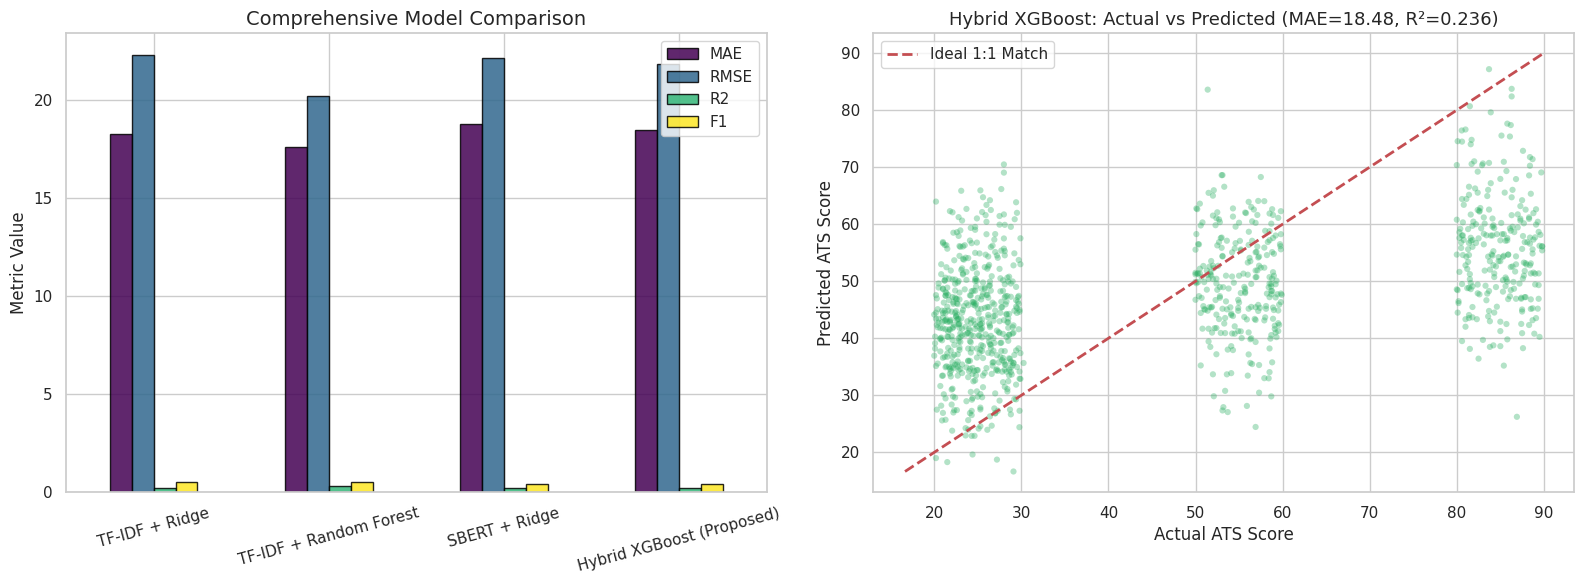

✅ Saved best hybrid model to models/hybrid_xgboost_tuned.joblib


In [9]:
from tabulate import tabulate

results_dict = {
    "TF-IDF + Ridge": res_ridge,
    "TF-IDF + Random Forest": res_rf,
    "SBERT + Ridge": res_sbert,
    "Hybrid XGBoost (Proposed)": res_hybrid,
}

df_results = pd.DataFrame(results_dict).T.round(4)
print(tabulate(df_results, headers="keys", tablefmt="fancy_grid"))

# Save metrics CSV
df_results.to_csv("outputs/model_comparison_results.csv")

# Final Evaluation Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Comparison Bar Chart
metrics_plot = ["MAE", "RMSE", "R2", "F1"]
df_results[metrics_plot].plot(kind="bar", ax=axes[0], colormap="viridis", edgecolor="black", alpha=0.85)
axes[0].set_title("Comprehensive Model Comparison", fontsize=14)
axes[0].set_ylabel("Metric Value")
axes[0].tick_params(axis='x', rotation=15)

# Plot 2: Actual vs Predicted (Hybrid Model)
axes[1].scatter(y_test, y_pred_hybrid, color="#27ae60", alpha=0.35, s=20, edgecolors="none")
min_v, max_v = min(y_test.min(), y_pred_hybrid.min()), max(y_test.max(), y_pred_hybrid.max())
axes[1].plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2, label="Ideal 1:1 Match")
axes[1].set_title(f"Hybrid XGBoost: Actual vs Predicted (MAE={res_hybrid['MAE']:.2f}, R²={res_hybrid['R2']:.3f})", fontsize=13)
axes[1].set_xlabel("Actual ATS Score")
axes[1].set_ylabel("Predicted ATS Score")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/figures/final_evaluation.png", dpi=200)
plt.show()

# Save models
joblib.dump(best_hybrid, "models/hybrid_xgboost_tuned.joblib")
print("✅ Saved best hybrid model to models/hybrid_xgboost_tuned.joblib")


---
# 🌐 Part 10: Interactive Gradio Deployment App (Runs directly in Colab!)


In [11]:
import gradio as gr

def predict_ats(resume_text, jd_text):
    if not resume_text.strip() or not jd_text.strip():
        return "Please input both resume and job description.", "", "", "", ""

    r_clean = clean_text(resume_text)
    j_clean = clean_text(jd_text)

    # 1. SBERT
    r_emb = sbert.encode([r_clean], convert_to_numpy=True)
    j_emb = sbert.encode([j_clean], convert_to_numpy=True)
    cos = cosine_similarity(r_emb, j_emb)[0, 0]
    diff = np.abs(r_emb - j_emb)

    # 2. Skills
    r_s = {s for s in ALL_SKILLS if s in r_clean}
    j_s = {s for s in ALL_SKILLS if s in j_clean}
    matched = sorted(r_s & j_s)
    missing = sorted(j_s - r_s)
    ratio = len(matched) / max(len(j_s), 1)

    # 3. Meta
    r_len, j_len = len(r_clean), len(j_clean)
    r_w = len(r_clean.split())
    j_w = len(j_clean.split())
    l_ratio = r_len / (j_len + 1)
    kw_overlap = len(set(r_clean.split()) & set(j_clean.split())) / max(len(set(j_clean.split())), 1)

    feats = np.hstack([
        np.array([[cos]]),
        diff,
        np.array([[len(r_s), len(j_s), len(matched), len(missing), ratio]]),
        np.array([[r_len, j_len, r_w, j_w, l_ratio, kw_overlap]])
    ])

    score = float(best_hybrid.predict(feats)[0])
    score = max(0, min(100, score))

    if score >= 65:
        category = "🟢 Good Fit"
    elif score >= 40:
        category = "🟡 Potential Fit"
    else:
        category = "🔴 No Fit"

    matched_str = "\n".join([f"• {s.title()}" for s in matched]) if matched else "None detected"
    missing_str = "\n".join([f"• {s.title()}" for s in missing]) if missing else "No missing skills!"

    details = f"**Semantic Cosine Similarity:** {cos:.4f}\n**Skill Match Ratio:** {ratio*100:.1f}% ({len(matched)}/{len(j_s)} skills)\n**Keyword Overlap:** {kw_overlap*100:.1f}%"

    return f"### Predicted ATS Score: {score:.1f} / 100", f"### Status: {category}", matched_str, missing_str, details

# Sample Data
SAMPLE_RESUME = '''Senior Software Engineer with 6 years of experience in Python, JavaScript, and Machine Learning.
Skilled in developing AI solutions using TensorFlow, PyTorch, scikit-learn, and FastAPI.
Extensive experience with AWS, Docker, CI/CD pipelines, and SQL databases. Strong background in NLP, teamwork, and problem solving.'''

SAMPLE_JD = '''Looking for a Machine Learning Engineer with 4+ years experience.
Must have strong expertise in Python, Machine Learning, Deep Learning, and NLP.
Experience with AWS, Docker, Kubernetes, and PostgreSQL required. Strong communication and collaboration skills.'''

app = gr.Interface(
    fn=predict_ats,
    inputs=[
        gr.Textbox(lines=8, label="📄 Candidate Resume", value=SAMPLE_RESUME),
        gr.Textbox(lines=8, label="💼 Job Description", value=SAMPLE_JD)
    ],
    outputs=[
        gr.Markdown(label="Score"),
        gr.Markdown(label="Category"),
        gr.Textbox(label="✅ Matched Skills", lines=5),
        gr.Textbox(label="❌ Missing Skills", lines=5),
        gr.Markdown(label="📊 Signal Breakdown")
    ],
    title="🎯 Hybrid NLP Resume–Job Matching System",
    description="Combines Sentence-BERT semantic similarity, curated skill dictionary extraction, and XGBoost regression to evaluate ATS compatibility.",
)

# Launch with shareable public link
app.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f0191ca64e0edb9ecd.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
# 📦 Step 11: Download All Artifacts & Figures (Zip)
Run the cell below to download all generated plots, model files, and CSV results to your computer.


In [12]:
!zip -r capstone_project_outputs.zip models/ outputs/
from google.colab import files
files.download("capstone_project_outputs.zip")
print("✅ Artifacts packaged and ready for download!")


  adding: models/ (stored 0%)
  adding: models/hybrid_xgboost_tuned.joblib (deflated 69%)
  adding: outputs/ (stored 0%)
  adding: outputs/model_comparison_results.csv (deflated 32%)
  adding: outputs/figures/ (stored 0%)
  adding: outputs/figures/eda_summary.png (deflated 8%)
  adding: outputs/figures/final_evaluation.png (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Artifacts packaged and ready for download!
